# Preprocessing dan Ekstraksi Fitur Data Polutan di Kecamatan Tanah Merah, Bangkalan 

## 1.  Tujuan Mengetahui Kualitas Udara di Daerah Masing-Masing

  - Pemantauan Kondisi Lingkungan: Mendapatkan gambaran akurat terkait tingkat polusi udara.
  - Identifikasi Tren dan Pola: Mengetahui waktu dan lokasi terjadinya lonjakan polusi.
  - Peringatan Dini (Early Warning System): Memberikan peringatan kepada masyarakat saat kualitas udara berbahaya.
  - Evaluasi Kebijakan: Mengukur efektivitas kebijakan lingkungan yang sudah berjalan.

## 2.  Manfaat

  - Bagi Masyarakat: Perlindungan kesehatan dari risiko penyakit pernapasan dan peningkatan kualitas hidup.
  - Bagi Pemerintah: Menjadi dasar pembuatan regulasi (Data-Driven Policy) dan membantu pencapaian Sustainable Development Goals (SDGs).
  - Bagi Bisnis & Industri: Membantu kepatuhan standar lingkungan (ESG) dan membuka peluang inovasi (seperti air purifier dll).
  - Bagi Akademisi & Peneliti: Menyediakan dataset yang valid untuk keperluan riset lanjutan terkait iklim dan kesehatan.

# Data Understanding
Tahap prapemrosesan ini memanfaatkan platform OpenEO untuk memproses data satelit Sentinel-5P Level-2 secara cloud-based, mengurangi beban komputasi lokal dengan melakukan agregasi spasial dan temporal langsung di server.

## Deskripsi Fitur
- **NO2 (Nitrogen Dioksida):** Gas berwarna coklat kemerahan dengan bau yang menyengat. Utamanya bersumber dari emisi kendaraan, pembangkit listrik, dan pembakaran bahan bakar fosil. Terpapar NO2 tingkat tinggi dapat merusak saluran pernapasan.

Pengecekan anomali (data aneh) dan *missing values* akan dieksplorasi lebih lanjut menggunakan *library* Pandas pada langkah akhir.

# Preprocessing dan Ekstraksi Fitur

Tahap ini mencakup seluruh alur kerja mulai dari pemrosesan awal data mentah (*data preprocessing*) hingga pembentukan representasi data (*feature extraction*) berbasis deret waktu (*time series*):

1. **Persiapan Lingkungan & Autentikasi Cloud (OpenEO):** Mengakses infrastruktur komputasi awan *Copernicus Data Space Ecosystem* (CDSE) melalui OpenID Connect (OIDC) untuk pemrosesan citra satelit di sisi server.
2. **Definisi Wilayah (AOI) & Ingesti Data Satelit:** Menentukan poligon koordinat spasial (*Area of Interest*) Kecamatan Tanah Merah (Kabupaten Bangkalan) dan memuat koleksi data satelit **Sentinel-5P Level-2** untuk polutan $\text{NO}_2$ rentang waktu 31 Agustus 2025 – 31 Agustus 2026.
3. **Agregasi Spasio-Temporal & Eksekusi Batch Job:** Mereduksi observasi satelit menjadi nilai rata-rata harian (*temporal aggregation*) dan rata-rata per wilayah AOI (*spatial aggregation*), lalu mengeksekusi komputasi batch di server dan mengunduh hasilnya dalam format NetCDF (.nc).
4. **Transformasi Format Data:** Mengonversi struktur file multidimensi NetCDF menjadi format tabular *DataFrame* (CSV) dengan standardisasi format tanggal (YYYY-MM-DD).
5. **Eksplorasi Kualitas Data & Deteksi Anomali:** Mengidentifikasi data hilang (*missing dates*) akibat orbit satelit/tutupan awan, serta mendeteksi nilai ekstrim (*outlier*) dan nilai konsentrasi negatif yang tidak valid secara fisik menggunakan algoritma *Isolation Forest*.
6. **Imputasi Missing Values & Pembersihan Outlier:** Mengubah anomali menjadi NaN, merekonstruksi deret tanggal harian lengkap 366 hari, dan menerapkan *Linear Interpolation* serta *backward/forward fill* untuk menghasilkan data kontinu yang utuh.
7. **Ekstraksi Fitur Deret Waktu (TSFEL):** Mengekstrak 68 fitur karakteristik sinyal deret waktu $\text{NO}_2$ yang mencakup domain statistik/temporal, frekuensi/spektral, fraktal/kompleksitas, dan wavelet menjadi satu set vektor fitur tabular (.csv) yang siap digunakan untuk pemodelan *Machine Learning*.

## 1. Persiapan Lingkungan dan Autentikasi
Langkah pertama adalah menginstal pustaka yang dibutuhkan dan melakukan autentikasi ke server Copernicus Data Space Ecosystem (CDSE) menggunakan OpenID Connect (OIDC).

In [1]:
!pip install openeo


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\HYPE AMD\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [2]:
import openeo

In [3]:
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


### Penjelasan kode autentikasi

Kode sebelumnya mengimpor pustaka `openeo`, kemudian membuat koneksi ke layanan OpenEO Copernicus Data Space. Fungsi `authenticate_oidc()` melakukan autentikasi menggunakan OpenID Connect sehingga notebook dapat mengakses koleksi data Sentinel-5P dan mengirim proses analisis ke server.

![Screenshot 2026-09-12 204241.png](<attachment:Screenshot 2026-09-12 204241.png>)
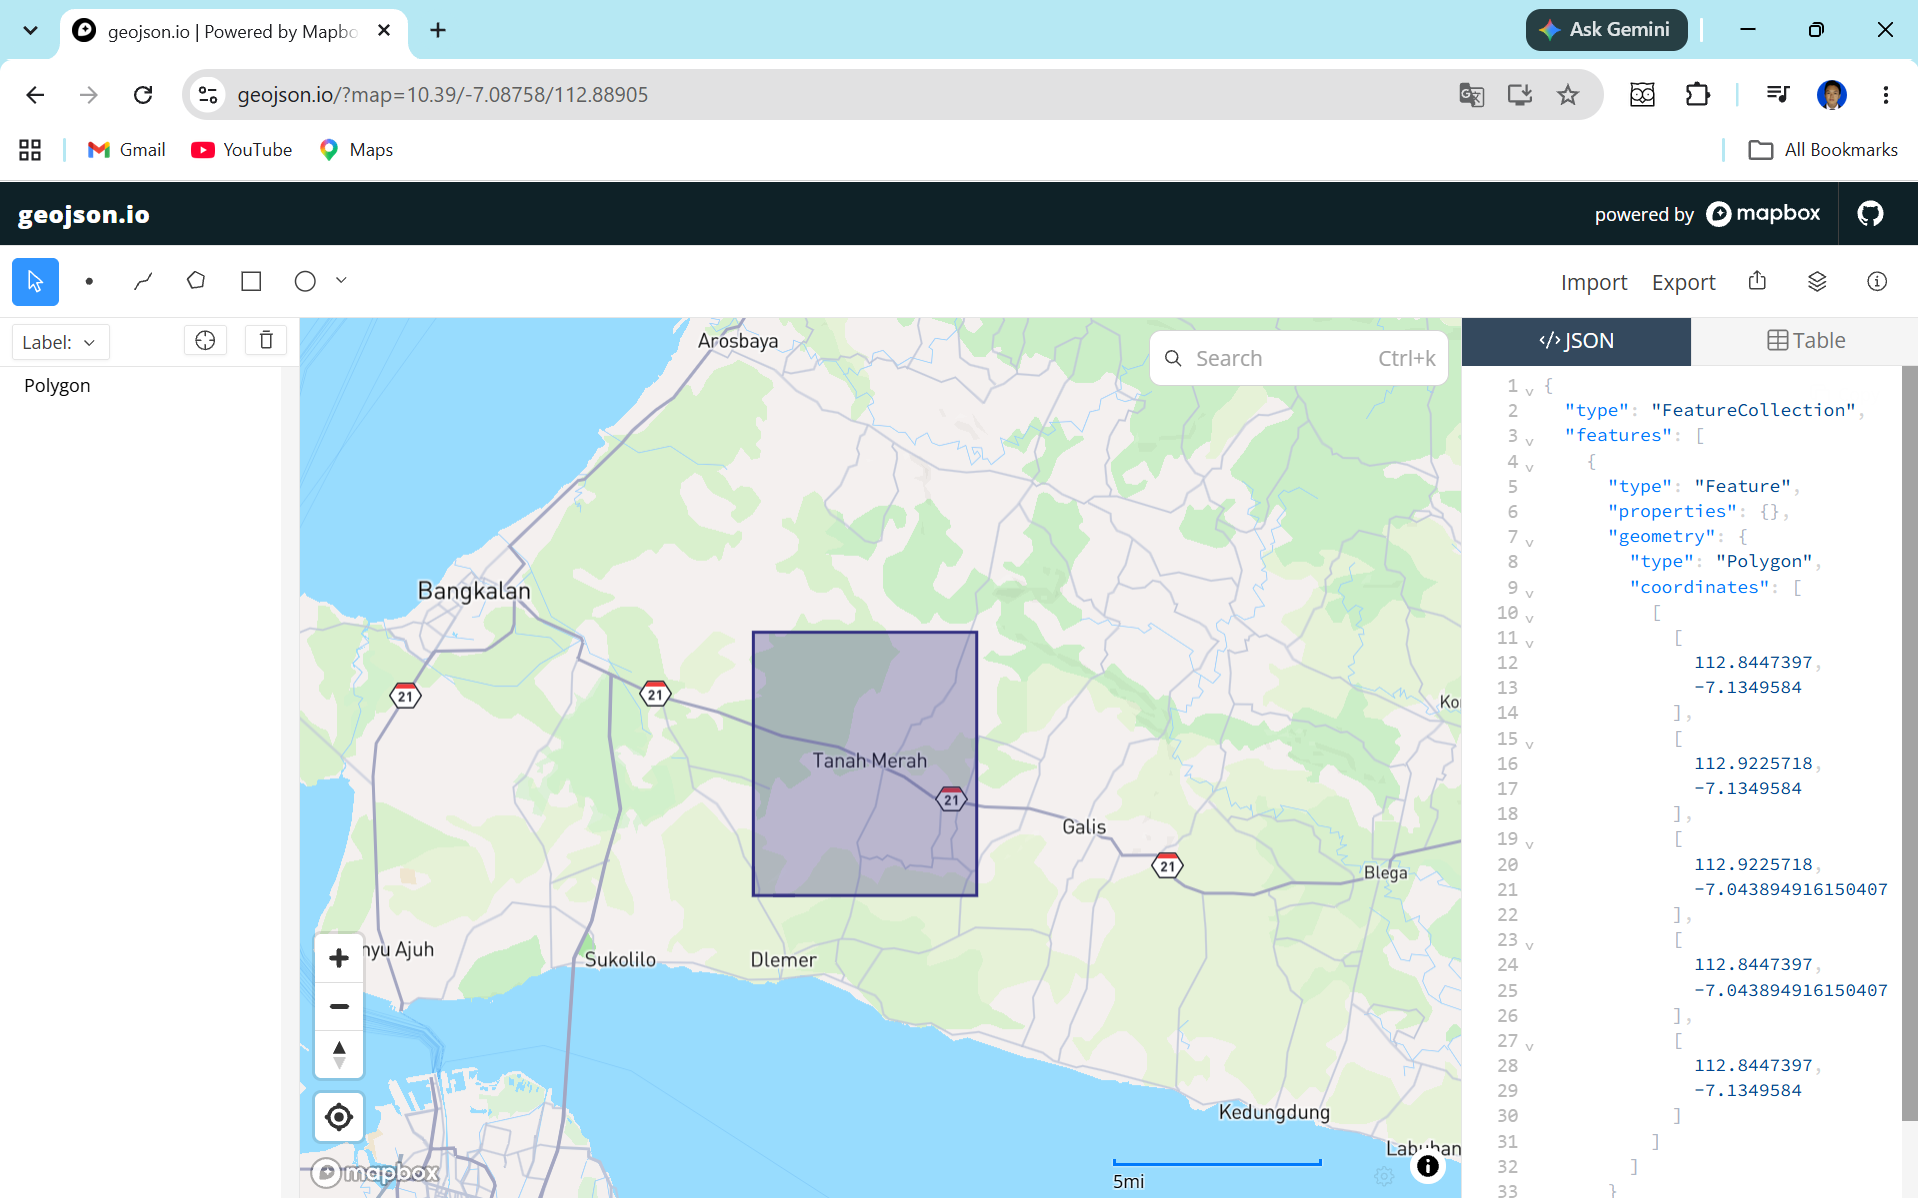

In [4]:
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
             [
              112.8447397,
              -7.1349584
            ],
            [
              112.9225718,
              -7.1349584
            ],
            [
              112.9225718,
              -7.043894916150407
            ],
            [
              112.8447397,
              -7.043894916150407
            ],
            [
              112.8447397,
              -7.1349584
            ]
          ]
    ]
}

s5NO2 = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-08-31"],
    spatial_extent={
        "west": 112.68,
        "south": -7.20,
        "east": 113.09,
        "north": -6.89
    },
    bands=["NO2"],
)



### Penjelasan kode pemanggilan data

Variabel `aoi` menyimpan batas wilayah Kabupaten Bangkalan dalam format GeoJSON Polygon. Fungsi `load_collection()` mengambil koleksi `SENTINEL_5P_L2` berdasarkan rentang waktu, batas koordinat, dan nama band polutan. Objek data dibuat untuk NO2 agar proses analisis dilakukan secara terpisah.

## 3. Agregasi Spasio-Temporal dan Eksekusi Server
Data satelit resolusi tinggi direduksi (diagregasi) menjadi nilai rata-rata harian (temporal) dan nilai rata-rata per wilayah AOI (spasial). Proses ini kemudian dikirim sebagai batch job untuk dieksekusi di server dan diunduh sebagai file NetCDF (.nc).

In [5]:
# agregasi berdasarkan hari untuk menghindari adanya beberapa data per hari
s5p_NO2_daily = s5NO2.aggregate_temporal_period(reducer="mean", period="day")
# agregasi untuk menghasilkan data deret waktu rata-rata
s5p_NO2_aoi = s5p_NO2_daily.aggregate_spatial(reducer="mean", geometries=aoi)

### Penjelasan kode agregasi

`aggregate_temporal_period(reducer="mean", period="day")` menghitung rata-rata data pada setiap hari. Setelah itu, `aggregate_spatial(reducer="mean", geometries=aoi)` menghitung rata-rata nilai di dalam wilayah AOI. Hasilnya adalah deret waktu harian yang mewakili kondisi rata-rata Kabupaten Bangkalan untuk setiap polutan.

In [6]:
# Eksekusi batch job dan unduh hasil ke format NetCDF (.nc)
job = s5p_NO2_aoi.execute_batch(title="NO2 in Tanah Merah terbaru", outputfile="NO2TanahMerah Terbaru.nc")

0:00:00 Job 'j-2609130958074be2bd3636c27a902318': send 'start'
0:00:03 Job 'j-2609130958074be2bd3636c27a902318': queued (progress 0%)
0:00:08 Job 'j-2609130958074be2bd3636c27a902318': queued (progress 0%)
0:00:15 Job 'j-2609130958074be2bd3636c27a902318': queued (progress 0%)
0:00:23 Job 'j-2609130958074be2bd3636c27a902318': queued (progress 0%)
0:00:33 Job 'j-2609130958074be2bd3636c27a902318': queued (progress 0%)
0:00:45 Job 'j-2609130958074be2bd3636c27a902318': queued (progress 0%)
0:01:01 Job 'j-2609130958074be2bd3636c27a902318': queued (progress 0%)
0:01:20 Job 'j-2609130958074be2bd3636c27a902318': running (progress N/A)
0:01:44 Job 'j-2609130958074be2bd3636c27a902318': running (progress N/A)
0:02:15 Job 'j-2609130958074be2bd3636c27a902318': running (progress N/A)
0:02:52 Job 'j-2609130958074be2bd3636c27a902318': running (progress N/A)
0:03:39 Job 'j-2609130958074be2bd3636c27a902318': finished (progress 100%)


### Penjelasan kode batch job

`execute_batch()` mengirim proses pengolahan data ke server OpenEO. Parameter `title` memberi nama pekerjaan, sedangkan `outputfile` menentukan nama file NetCDF yang diunduh setelah proses selesai.

## 4. Transformasi Data (NetCDF ke CSV)
Membaca file multi-dimensi NetCDF hasil unduhan, mengekstrak nilai polutan beserta atribut waktunya, melakukan penyesuaian format tanggal (YYYY-MM-DD), dan merestrukturisasinya menjadi format DataFrame menggunakan Pandas untuk disimpan sebagai CSV.

In [7]:
!pip install netCDF4


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\HYPE AMD\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [8]:
import netCDF4
import numpy as np
import pandas as pd

def safe_date_list(time_values, units=None):
    try:
        if units:
            dates = netCDF4.num2date(time_values, units=units)
        else:
            dates = time_values
    except Exception:
        dates = time_values

    out = []
    for value in dates:
        if hasattr(value, "strftime"):
            out.append(value.strftime("%Y-%m-%d"))
        elif isinstance(value, np.datetime64):
            out.append(pd.to_datetime(str(value)).strftime("%Y-%m-%d"))
        else:
            try:
                out.append(pd.to_datetime(value).strftime("%Y-%m-%d"))
            except Exception:
                out.append(str(value))
    return out

dsNO2 = netCDF4.Dataset("NO2TanahMerah Terbaru.nc")

In [9]:
values = np.asarray(dsNO2.variables["NO2"][:])
if values.ndim > 1:
    values = values.squeeze()

timeNO2 = dsNO2.variables["t"][:]
unitsNO2 = getattr(dsNO2.variables["t"], "units", None)
dates = safe_date_list(timeNO2, unitsNO2)

if len(dates) != len(values):
    n = min(len(dates), len(values))
    dates = dates[:n]
    values = values[:n]

df = pd.DataFrame({
    "date": dates,
    "NO2": values
})

df.to_csv("NO2_TanahMerah_timeseries_terbaru.csv", index=False)

In [10]:
import pandas as pd

df_no2 = pd.read_csv("NO2_TanahMerah_timeseries_terbaru.csv")
df_no2['NO2'] = pd.to_numeric(df_no2['NO2'], errors='coerce')
df_no2['date'] = pd.to_datetime(df_no2['date'])

print("========== Pengecekan Missing Values ==========")
print(df_no2.isnull().sum())
print("\n========== Pengecekan Data Aneh (Deskripsi Statistik) ==========")
print(df_no2.describe())

========== Pengecekan Missing Values ==========
date    0
NO2     0
dtype: int64

========== Pengecekan Data Aneh (Deskripsi Statistik) ==========
                                date         NO2
count                            187  187.000000
mean   2026-04-01 10:31:26.631015936    0.000024
min              2025-08-31 00:00:00   -0.000007
25%              2025-12-24 00:00:00    0.000015
50%              2026-05-05 00:00:00    0.000024
75%              2026-07-07 12:00:00    0.000030
max              2026-08-30 00:00:00    0.000063
std                              NaN    0.000012


### Penjelasan kode eksplorasi data

File CSV NO2 dibaca menggunakan Pandas dan nilai polutan dikonversi menjadi numerik dengan `errors="coerce"` sehingga teks yang tidak valid berubah menjadi nilai kosong. `isnull().sum()` menghitung data yang hilang, sedangkan `describe()` menampilkan jumlah data, rata-rata, standar deviasi, nilai minimum, kuartil, dan maksimum.

# 6. Missing values

### Penjelasan bagian Missing Values

Missing value adalah data yang tidak memiliki nilai pengamatan atau bernilai kosong. Pemeriksaan pada bagian ini dilakukan dengan dua cara:

1. **Pengecekan tanggal yang hilang:** `pd.date_range()` membuat daftar tanggal harian lengkap dari **31 Agustus 2025 sampai 31 Agustus 2026**. Method `difference()` membandingkan daftar tersebut dengan kolom `date` untuk menemukan tanggal yang tidak tersedia pada data NO2.
2. **Pengecekan nilai kosong:** `isna().sum()` menghitung jumlah nilai kosong pada kolom konsentrasi NO2. Nilai kosong dapat terjadi karena tidak ada observasi satelit yang valid pada tanggal atau wilayah tertentu akibat tutupan awan atau jadwal orbit.

## NO2

In [11]:
import pandas as pd

df = pd.read_csv("NO2_TanahMerah_timeseries_terbaru.csv")
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap sesuai periode pengambilan data (31-08-2025 s/d 31-08-2026)
start_date = "2025-08-31"
end_date   = "2026-08-31"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Cek tanggal yang hilang
missing_dates = full_range.difference(df['date'])

print(f"Rentang Analisis: {start_date} s/d {end_date}")
print(f"Total Hari Diharapkan: {len(full_range)}")
print(f"Jumlah Hari Ada Data : {len(df)}")
print(f"Jumlah Hari Missing  : {len(missing_dates)}")
print("\nBeberapa Contoh Tanggal Missing:")
print(missing_dates[:10])

Rentang Analisis: 2025-08-31 s/d 2026-08-31
Total Hari Diharapkan: 366
Jumlah Hari Ada Data : 187
Jumlah Hari Missing  : 179

Beberapa Contoh Tanggal Missing:
DatetimeIndex(['2025-09-02', '2025-09-10', '2025-09-16', '2025-09-17',
               '2025-09-18', '2025-09-19', '2025-09-20', '2025-09-21',
               '2025-09-29', '2025-09-30'],
              dtype='datetime64[ns]', freq=None)


# 7. Outliers

NO2

In [14]:
import pandas as pd
from sklearn.ensemble import IsolationForest

df = pd.read_csv("NO2_TanahMerah_timeseries_terbaru.csv")
df['date'] = pd.to_datetime(df['date'])
df_clean = df.dropna(subset=['NO2']).copy()

model = IsolationForest(contamination=0.05, random_state=42)
pred = model.fit_predict(df_clean[['NO2']])

df_clean['is_outlier'] = pred
jumlah_outlier = (pred == -1).sum()
print("Jumlah outlier terdeteksi:", jumlah_outlier)
print("\nContoh data outlier:")
print(df_clean[df_clean['is_outlier'] == -1].head())

Jumlah outlier terdeteksi: 10

Contoh data outlier:
         date       NO2  is_outlier
0  2025-08-31 -0.000007          -1
29 2025-10-17 -0.000006          -1
35 2025-11-25  0.000053          -1
51 2026-01-08  0.000063          -1
70 2026-03-09  0.000060          -1


### Penjelasan kode deteksi outlier

`dropna()` menghapus baris yang tidak memiliki nilai polutan. `IsolationForest` kemudian dilatih menggunakan satu kolom polutan untuk mengidentifikasi nilai yang berbeda jauh dari pola umum. Hasil `-1` dianggap sebagai outlier, sedangkan hasil `1` dianggap sebagai data normal. Parameter `contamination=0.05` memperkirakan sekitar 5% data sebagai outlier.

# 8. Imputasi Missing Value & Penanganan Outlier
### Penjelasan Tahapan Imputasi & Penanganan Outlier:
1. **Penanganan Outlier & Nilai Negatif**: Nilai fisik konsentrasi polutan NO2 troposferik tidak boleh negatif. Nilai negatif dan data outlier yang terdeteksi oleh *Isolation Forest* diubah menjadi `NaN` agar dapat diestimasi ulang secara akurat.
2. **Reindexing Deret Waktu Harian**: Deret tanggal direstrukturisasi menjadi tanggal harian penuh dari **31-08-2025 sampai 31-08-2026** (366 hari).
3. **Imputasi Deret Waktu**: Nilai kosong (`NaN`) diisi menggunakan **Interpolasi Linier Deret Waktu** (Linear Interpolation) serta *backward/forward fill* untuk batas rentang data.

In [15]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest

# 1. Membaca data time-series asli
df = pd.read_csv("NO2_TanahMerah_timeseries_terbaru.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').drop_duplicates('date').reset_index(drop=True)

# 2. Penanganan Nilai Negatif & Deteksi Outliers
# Nilai negatif polutan diubah menjadi NaN
df.loc[df['NO2'] < 0, 'NO2'] = np.nan

# Deteksi Outlier dengan Isolation Forest
valid_idx = df[df['NO2'].notna()].index
iso = IsolationForest(contamination=0.05, random_state=42)
preds = iso.fit_predict(df.loc[valid_idx, ['NO2']])
outlier_idx = valid_idx[preds == -1]

# Ubah outlier menjadi NaN untuk diimputasi
df.loc[outlier_idx, 'NO2'] = np.nan

# 3. Pembentukan Deret Tanggal Lengkap (31-08-2025 s/d 31-08-2026)
full_dates = pd.date_range(start="2025-08-31", end="2026-08-31", freq="D")
df_imputed = df.set_index('date').reindex(full_dates)
df_imputed.index.name = 'date'
df_imputed = df_imputed.reset_index()

# 4. Imputasi Missing Values menggunakan Linear Interpolation
df_imputed['NO2'] = df_imputed['NO2'].interpolate(method='linear')
df_imputed['NO2'] = df_imputed['NO2'].bfill().ffill()

print("Proses imputasi missing value dan pembersihan outlier berhasil dilakukan!")

Proses imputasi missing value dan pembersihan outlier berhasil dilakukan!


# 9. Data Sempurna (Bebas Outliers & Missing Value)
### Verifikasi Data Akhir:
Memastikan dataset deret waktu telah lengkap (31-08-2025 s/d 31-08-2026), tidak memiliki *missing values*, tidak ada nilai anomali/negatif, dan menyimpan hasil akhir ke file `Polutan_Bangkalan.csv` serta `NO2_TanahMerah_timeseries_clean.csv`.

In [16]:
print("========== VERIFIKASI DATA SEMPURNA ==========")
print(f"1. Rentang Tanggal : {df_imputed['date'].min().strftime('%Y-%m-%d')} s/d {df_imputed['date'].max().strftime('%Y-%m-%d')}")
print(f"2. Total Hari      : {len(df_imputed)} hari (Lengkap 100%)")
print(f"3. Missing Values  : {df_imputed.isnull().sum().sum()} (Bebas Missing Value)")
print(f"4. Nilai Negatif   : {(df_imputed['NO2'] < 0).sum()} (Bebas Nilai Negatif)")

print("\n========== DESKRIPSI STATISTIK DATA BERSIH ==========")
print(df_imputed.describe())

# Simpan dataset final yang sempurna
df_imputed.to_csv("Polutan_Bangkalan.csv", index=False)
df_imputed.to_csv("NO2_TanahMerah_timeseries_clean.csv", index=False)
print("\nDataset sempurna berhasil disimpan ke 'Polutan_Bangkalan.csv' dan 'NO2_TanahMerah_timeseries_clean.csv'!")

========== VERIFIKASI DATA SEMPURNA ==========
1. Rentang Tanggal : 2025-08-31 s/d 2026-08-31
2. Total Hari      : 366 hari (Lengkap 100%)
3. Missing Values  : 0 (Bebas Missing Value)
4. Nilai Negatif   : 0 (Bebas Nilai Negatif)

========== DESKRIPSI STATISTIK DATA BERSIH ==========
                                date         NO2
count                            366  366.000000
mean   2026-03-01 12:00:00.000000256    0.000025
min              2025-08-31 00:00:00    0.000003
25%              2025-11-30 06:00:00    0.000020
50%              2026-03-01 12:00:00    0.000026
75%              2026-05-31 18:00:00    0.000031
max              2026-08-31 00:00:00    0.000047
std                              NaN    0.000008

Dataset sempurna berhasil disimpan ke 'Polutan_Bangkalan.csv' dan 'NO2_TanahMerah_timeseries_clean.csv'!


In [17]:
print("========== 5 BARIS PERTAMA DATA SEMPURNA ==========")
print(df_imputed.head())
print("\n========== 5 BARIS TERAKHIR DATA SEMPURNA ==========")
print(df_imputed.tail())

========== 5 BARIS PERTAMA DATA SEMPURNA ==========
        date       NO2
0 2025-08-31  0.000015
1 2025-09-01  0.000015
2 2025-09-02  0.000014
3 2025-09-03  0.000013
4 2025-09-04  0.000004

========== 5 BARIS TERAKHIR DATA SEMPURNA ==========
          date       NO2
361 2026-08-27  0.000043
362 2026-08-28  0.000027
363 2026-08-29  0.000027
364 2026-08-30  0.000027
365 2026-08-31  0.000027


In [2]:
!pip install tsfel


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\HYPE AMD\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

# ---------- 1. Muat dan bersihkan data ----------
df = pd.read_csv('NO2_TanahMerah_timeseries_clean.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

target_pollutant = 'NO2'

# --- FIX: paksa kolom target jadi numerik, nilai yang gagal dikonversi -> NaN ---
df[target_pollutant] = pd.to_numeric(df[target_pollutant], errors='coerce')

n_missing_before = df[target_pollutant].isna().sum()
print(f"Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: {n_missing_before}")

Q1 = df[target_pollutant].quantile(0.25)
Q3 = df[target_pollutant].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df.loc[(df[target_pollutant] < lower_bound) | (df[target_pollutant] > upper_bound), target_pollutant] = np.nan

df_clean = df.set_index('date').interpolate(method='time').ffill().bfill()

fs = 1
signal_1d = df_clean[target_pollutant].astype(float).values

# ---------- 2. Daftar PERSIS fitur yang diminta ----------
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print("Jumlah fitur yang diminta:", len(FEATURE_LIST))


def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)


row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

extracted_features_final = pd.DataFrame([row])

print(f"Berhasil! Jumlah fitur yang dihasilkan untuk {target_pollutant}: {extracted_features_final.shape[1]}")
extracted_features_final.to_csv(f'{target_pollutant}_TanahMerah_TSFEL.csv', index=False)

Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: 0
Jumlah fitur yang diminta: 68
Berhasil! Jumlah fitur yang dihasilkan untuk NO2: 68


In [4]:
# Menampilkan tabel hasil ekstraksi fitur TSFEL
df_tsfel = pd.read_csv('NO2_TanahMerah_TSFEL.csv')
df_tsfel

,abs_energy,auc,autocorr,average_power,calc_centroid,calc_max,calc_mean,calc_median,calc_min,calc_std,calc_var,dfa,distance,ecdf,ecdf_percentile,ecdf_percentile_count,ecdf_slope,entropy,fundamental_frequency,higuchi_fractal_dimension,hist_mode,human_range_energy,hurst_exponent,interq_range,kurtosis,lempel_ziv,lpcc,max_frequency,max_power_spectrum,maximum_fractal_length,mean_abs_deviation,mean_abs_diff,mean_diff,median_abs_deviation,median_abs_diff,median_diff,median_frequency,mfcc,mse,negative_turning,neighbourhood_peaks,petrosian_fractal_dimension,pk_pk_distance,positive_turning,power_bandwidth,rms,skewness,slope,spectral_centroid,spectral_decrease,spectral_distance,spectral_entropy,spectral_kurtosis,spectral_positive_turning,spectral_roll_off,spectral_roll_on,spectral_skewness,spectral_slope,spectral_spread,spectral_variation,spectrogram_mean_coeff,sum_abs_diff,wavelet_abs_mean,wavelet_energy,wavelet_entropy,wavelet_std,wavelet_var,zero_cross
0,2.608035e-07,0.009258,4.0,7.145301e-10,170.256154,0.000047,0.000025,0.000026,0.000004,0.000008,6.979190e-11,1.146748,365.0,0.015027,0.000025,182.5,52791.11553,0.996792,0.002732,1.847039,0.000027,0.0,0.8231,0.000011,-0.15595,0.163934,0.737113,0.42623,55.971131,-2.721974,0.000007,0.000004,3.165045e-08,0.000005,0.000002,-1.386292e-07,0.057377,20.297615,1.044248,52.0,12.0,1.018922,0.000043,52.0,0.297814,0.000027,-0.038668,-1.669431e-08,0.122597,-2.420345,-1.44336,0.739665,2.787968,54.0,0.42623,0.0,1.026317,-0.032876,0.145286,0.36294,9.636304e-11,0.001437,0.000001,0.000012,2.14052,0.000012,1.625591e-10,0.0


# Penjelasan Fitur tsfel

Berikut adalah penjelasan lengkap mengenai **68 fitur deret waktu (*time series features*)** yang diekstrak menggunakan pustaka **TSFEL (*Time Series Feature Extraction Library*)** untuk analisis konsentrasi polutan NO2:

---

### 1. Domain Statistik & Karakteristik Dasar Sinyal (Statistical & Temporal Domain)
Fitur-fitur ini mendeskripsikan distribusi nilai, pusat data, dispersi, dan energi keseluruhan dari deret waktu:

* **`calc_mean` (Mean):** Nilai rata-rata konsentrasi polutan NO2 selama periode pengamatan.
* **`calc_median` (Median):** Nilai tengah data setelah diurutkan, tahan terhadap pencilan (*outliers*).
* **`calc_min` (Minimum):** Nilai konsentrasi NO2 terendah yang tercatat.
* **`calc_max` (Maximum):** Nilai konsentrasi NO2 tertinggi yang tercatat.
* **`calc_std` (Standard Deviation):** Mengukur dispersi atau seberapa jauh data tersebar dari nilai rata-rata.
* **`calc_var` (Variance):** Varians data (kuadrat standar deviasi), menggambarkan volatilitas polutan.
* **`calc_centroid` (Centroid):** Titik pusat massa distribusi waktu dari sinyal.
* **`skewness` (Kemencengan):** Derajat asimetri distribusi data terhadap nilai rata-ratanya.
* **`kurtosis` (Keruncingan):** Tingkat keruncingan distribusi dan ketebalan ekor data (*tail risk*).
* **`interq_range` (Interquartile Range / IQR):** Rentang interkuartil (Q3 - Q1), mengukur sebaran data pada 50% data tengah.
* **`hist_mode` (Histogram Mode):** Nilai konsentrasi yang paling sering muncul berdasarkan binning histogram.
* **`rms` (Root Mean Square):** Nilai akar kuadrat rata-rata kuadrat sinyal, mengukur magnitudo kekuatan sinyal.
* **`abs_energy` (Absolute Energy):** Jumlah kuadrat dari seluruh nilai sinyal, menunjukkan total energi NO2.
* **`average_power` (Average Power):** Rata-rata daya sinyal (total energi dibagi dengan panjang data).
* **`auc` (Area Under Curve):** Total luas area di bawah kurva deret waktu menggunakan integrasi numerik trapesium.
* **`autocorr` (Autocorrelation):** Tingkat korelasi sinyal dengan dirinya sendiri pada jeda waktu (*lag*), menunjukkan memori deret waktu.
* **`mean_abs_deviation` (Mean Absolute Deviation):** Rata-rata simpangan mutlak setiap titik terhadap nilai rata-rata (*mean*).
* **`median_abs_deviation` (Median Absolute Deviation):** Median dari simpangan mutlak setiap titik terhadap median.

---

### 2. Domain Dinamika Perubahan & Titik Balik (Temporal Dynamics & Turning Points)
Fitur-fitur ini mengukur laju variasi harian, kestabilan perubahan, dan bentuk lintasan sinyal:

* **`mean_diff` (Mean First Difference):** Rata-rata selisih perubahan harian antar-titik waktu berurutan ($x_t - x_{t-1}$).
* **`mean_abs_diff` (Mean Absolute First Difference):** Rata-rata perubahan absolut harian ($|x_t - x_{t-1}|$).
* **`median_diff` (Median First Difference):** Median dari selisih perubahan antar-waktu berurutan.
* **`median_abs_diff` (Median Absolute First Difference):** Median dari perubahan absolut harian.
* **`sum_abs_diff` (Sum of Absolute Differences):** Akumulasi total seluruh perubahan absolut sepanjang periode.
* **`distance` (Cumulative Distance):** Total jarak lintasan sinyal titik demi titik sepanjang kurva.
* **`slope` (Linear Trend Slope):** Kemiringan garis regresi linier yang menunjukkan arah tren jangka panjang NO2 (naik/turun).
* **`positive_turning` (Positive Turning Points):** Jumlah titik belok lokal puncak (perubahan arah dari naik menjadi turun).
* **`negative_turning` (Negative Turning Points):** Jumlah titik belok lokal lembah (perubahan arah dari turun menjadi naik).
* **`neighbourhood_peaks` (Neighbourhood Peaks):** Jumlah puncak lokal yang menonjol dibandingkan tetangga sekitarnya.
* **`pk_pk_distance` (Peak-to-Peak Distance):** Selisih rentang absolut antara nilai puncak tertinggi dan lembah terendah ($x_{max} - x_{min}$).
* **`zero_cross` (Zero Crossing Rate):** Frekuensi sinyal melintasi garis nol atau nilai referensi tengah.

---

### 3. Domain Distribusi Probabilitas Empiris (ECDF Features)
Mengkarakterisasi fungsi distribusi kumulatif empiris (*Empirical Cumulative Distribution Function*):

* **`ecdf` (ECDF Mean):** Nilai rata-rata integral dari fungsi distribusi kumulatif empiris.
* **`ecdf_percentile` (ECDF Percentile):** Nilai kuantil/persentil tertentu pada kurva ECDF.
* **`ecdf_percentile_count` (ECDF Percentile Count):** Jumlah sampel data yang berada di bawah persentil tertentu kurva ECDF.
* **`ecdf_slope` (ECDF Slope):** Kemiringan kurva ECDF yang merefleksikan laju akumulasi probabilitas konsentrasi.

---

### 4. Domain Fraktalitas & Kompleksitas Non-Linier (Fractal & Complexity Domain)
Mengukur keteraturan, ketidakpastian, dan struktur skala fraktal sinyal:

* **`entropy` (Shannon Entropy):** Mengukur tingkat keacakan, ketidakpastian, atau kekacauan informasi dalam sinyal.
* **`hurst_exponent` (Hurst Exponent):** Eksponen Hurst yang mengukur persistensi tren deret waktu ($H > 0.5$ mengindikasikan persistensi tren, $H = 0.5$ gerak acak, $H < 0.5$ mean-reverting).
* **`dfa` (Detrended Fluctuation Analysis):** Mengukur korelasi jangka panjang (*long-range auto-correlation*) pada sinyal non-stasioner.
* **`higuchi_fractal_dimension` (Higuchi Fractal Dimension):** Dimensi fraktal Higuchi untuk mengukur kekasaran dan kompleksitas geometrik kurva deret waktu.
* **`petrosian_fractal_dimension` (Petrosian Fractal Dimension):** Dimensi fraktal Petrosian berdasarkan perubahan tanda turunan pertama sinyal.
* **`maximum_fractal_length` (Maximum Fractal Length):** Panjang kurva fraktal maksimum yang diukur pada skala analisis tertentu.
* **`lempel_ziv` (Lempel-Ziv Complexity):** Mengukur laju kemunculan pola atau subunit baru di dalam deret waktu.
* **`mse` (Mean Squared Error / Multiscale Complexity):** Mengukur variasi energi kesalahan rata-rata pada skala sinyal.

---

### 5. Domain Frekuensi & Spektral (Spectral / Frequency Domain)
Menggambarkan karakteristik periodisitas, kerapatan spektral daya (*Power Spectral Density*), dan distribusi frekuensi:

* **`fundamental_frequency` (Fundamental Frequency):** Frekuensi dasar terendah yang paling dominan dalam sinyal NO2.
* **`max_frequency` (Maximum Frequency):** Frekuensi yang memiliki amplitudo/respon spektral tertinggi.
* **`median_frequency` (Median Frequency):** Frekuensi yang membagi dua spektrum daya secara seimbang (50% daya di bawah dan 50% di atas).
* **`max_power_spectrum` (Max Power Spectrum):** Kerapatan spektral daya maksimum (*peak power density*).
* **`power_bandwidth` (Power Bandwidth):** Lebar pita frekuensi (*bandwidth*) yang mencakup sebagian besar energi spektrum.
* **`spectral_centroid` (Spectral Centroid):** Pusat massa frekuensi dari spektrum daya (*center of mass* frekuensi).
* **`spectral_spread` (Spectral Spread):** Lebar sebaran spektral di sekitar centroid frekuensi (varians spektral).
* **`spectral_skewness` (Spectral Skewness):** Derajat asimetri distribusi energi spektrum daya.
* **`spectral_kurtosis` (Spectral Kurtosis):** Keruncingan distribusi energi spektral frekuensi.
* **`spectral_entropy` (Spectral Entropy):** Mengukur kerataan distribusi spektral (apakah acak seperti *white noise* atau terpusat pada frekuensi tertentu).
* **`spectral_slope` (Spectral Slope):** Kemiringan garis penurunan spektrum daya terhadap peningkatan frekuensi.
* **`spectral_decrease` (Spectral Decrease):** Laju penurunan energi spektrum pada pita frekuensi tinggi.
* **`spectral_distance` (Spectral Distance):** Jarak penyimpangan distribusi spektral terhadap profil spektrum acuan.
* **`spectral_roll_off` (Spectral Roll-off):** Frekuensi batas bawah di mana 85-95% total energi spektral terkonsentrasi.
* **`spectral_roll_on` (Spectral Roll-on):** Frekuensi awal di mana energi spektral mulai terkumpul.
* **`spectral_variation` (Spectral Variation):** Fluktuasi/variasi bentuk energi spektral antar-frekuensi.
* **`spectral_positive_turning` (Spectral Positive Turning Points):** Jumlah puncak/titik balik positif pada kurva spektrum daya.
* **`spectrogram_mean_coeff` (Spectrogram Mean Coefficient):** Rata-rata koefisien dari matriks spektrogram waktu-frekuensi.
* **`human_range_energy` (Human Range Energy):** Rasio energi sinyal pada rentang frekuensi tertentu yang relevan.
* **`lpcc` (Linear Prediction Cepstral Coefficients):** Koefisien kepstral hasil pemodelan linier untuk mendeskripsikan amplop spektrum.
* **`mfcc` (Mel-Frequency Cepstral Coefficients):** Koefisien kepstral frekuensi Mel yang memetakan energi spektral non-linier.

---

### 6. Domain Transformasi Wavelet (Wavelet Domain)
Menganalisis sinyal multiskala menggunakan dekomposisi koefisien wavelet (*Wavelet Transform*):

* **`wavelet_energy` (Wavelet Energy):** Total akumulasi energi dari koefisien dekomposisi wavelet.
* **`wavelet_entropy` (Wavelet Entropy):** Tingkat entropi/ketidakteraturan distribusi energi koefisien wavelet multiskala.
* **`wavelet_abs_mean` (Wavelet Absolute Mean):** Rata-rata nilai absolut koefisien wavelet.
* **`wavelet_std` (Wavelet Standard Deviation):** Standar deviasi dari koefisien wavelet, menggambarkan dispersi energi gelombang.
* **`wavelet_var` (Wavelet Variance):** Varians koefisien wavelet.